In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# import necessary packages
import numpy as np
import matplotlib.pyplot as plt
import xso

from Stocketal2008_comps import (Nutrient, PhytoSizeSpectrum, ZooSizeSpectrum, 
    ConstantExternalNutrient, LinearForcingInput, 
    MonodGrowth_SizeBased, 
    StockGrazingMatrix, Stock_GGE_MatrixGrazing, 
    StockPhytoMortality, StockZooMortality, StockZooMortality_simpleinput)



# number size classes of phytoplankton and zooplankton
P_num = 3
Z_num = 4

# create initial biomass
phyto_init = np.tile(0.5, (P_num)) #[0.18, 0.42, 0.067] #np.tile(0.5, (P_num))
zoo_init = np.tile(.1, (Z_num)) #[0.17,0.38,0.34,0.29] #np.tile(.1, (Z_num))

# calculate log-spaced size classes from ranges and total number
phyto_sizes = [0.63, 6.3, 63]
zoo_sizes = [6.3, 63, 630, 6300]

# Phytoplankton parameters
phyto_ks = [0.062, 0.45, 3.3]
phyto_mu0 = [1.0, 1.26, 0.42]
phyto_mortality = [1.0, 0, 0]
phyto_mort_exponent = [2.0, 1.0, 1.0]
phyto_recycling = [1.0, 0.0, 0.0]

# Zooplankton parameters
zoo_imax = [10.0, 3.3, 1.1, 0.36]
zoo_Ki = 3.0
zoo_frac_assim = 0.7  # alpha
zoo_frac_excreted = 0.45  # R
zoo_gge = 0.25
# prey availability: basically just 1 for size class below of Z and P, no other grazing! issa matrix 4 x 7
zoo_prey_avail = np.array([[1, 0, 0, 0, 0, 0, 0], # Z1
                          [0, 1, 0, 1, 0, 0, 0], # Z2
                          [0, 0, 1, 0, 1, 0, 0], # Z3
                          [0, 0, 0, 0, 0, 1, 0]]) # Z4

# dens dep prey exploitation factor
zoo_frac_egest_recycled = [1, 1, 0, 0]

# zoo mortality
zoo_higherordermortality = 0.0033
zoo_mortality_array = [0, 0, 0, zoo_higherordermortality]
zoo_mort_exponent = [0, 0, 0, 1]
zoo_frac_mortylity_recycled = [0, 0, 0, 0.5]



nutrient_input = 0.0017



model = xso.create({
            # State variables
            'Nutrient': Nutrient,
            'Phytoplankton': PhytoSizeSpectrum,
            'Zooplankton': ZooSizeSpectrum,
        
            # Flows:
            'Inflow': LinearForcingInput,
        
            # Growth
            'Growth': MonodGrowth_SizeBased,
        
            # Grazing
            'Grazing': StockGrazingMatrix,
            'GGE': Stock_GGE_MatrixGrazing,
        
            # Mortality
            'PhytoMortality': StockPhytoMortality,
            'HigherOrderMortality': StockZooMortality_simpleinput,
        
            # Forcings
            'N0': ConstantExternalNutrient,
        })
        
model_setup = xso.setup(solver='solve_ivp', model=model,
        time=np.arange(5000),
        input_vars={
                # State variables
                'Nutrient':{'value_label':'N','value_init':1.0},
                'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
             
                'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
            
                # Flows:
                'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
            
                # Growth
                'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

                # Grazing
                'Grazing':{'resource':'P', 'consumer':'Z', 'Imax':zoo_imax, 'KsZ':zoo_Ki, 'phiPZ':zoo_prey_avail},
                'GGE':{'grazed_phyto':'P', 'grazed_zoo':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
                       'R':zoo_frac_excreted, 'alpha':zoo_frac_assim, 'f_I':zoo_frac_egest_recycled, 'gge':zoo_gge},
            
                # Mortality
                'PhytoMortality':{'population':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},
                'HigherOrderMortality':{'population':'Z', 'nutrient':'N', 'rate':zoo_higherordermortality, 'exponent':zoo_mort_exponent, 'recycling':zoo_frac_mortylity_recycled},
 # Forcings
                'N0':{'forcing_label':'N0', 'value':nutrient_input},
        })

In [2]:
with model:
        model_out = model_setup.xsimlab.run()

No event detected


In [12]:
P0 = model_out.Phytoplankton__biomass.isel(time=slice(365*9,365*10)).mean(dim='time').values#.plot.line(x='time')
Z0 = model_out.Zooplankton__biomass.isel(time=slice(365*9,365*10)).mean(dim='time').values
N0 = model_out.Nutrient__value.isel(time=slice(365*9,365*10)).mean(dim='time').values #+0.1
print("N",N0)
print("P",P0)
print("Z",Z0)

N 0.13422694407484978
P [0.07437075 0.12718173 0.01103988]
Z [0.08644258 0.10284653 0.1141523  0.07927936]


In [10]:
model_setup_2 = xso.setup(solver='fsolve', model=model,
        time=[0,1],
        input_vars={
                # State variables
                'Nutrient':{'value_label':'N','value_init':N0},
                'Phytoplankton':{'biomass_label':'P','biomass_init':P0, 'phyto_index':phyto_sizes},
             
                'Zooplankton':{'biomass_label':'Z','biomass_init':Z0, 'zoo_index': zoo_sizes},
            
                # Flows:
                'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
            
                # Growth
                'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

                # Grazing
                'Grazing':{'resource':'P', 'consumer':'Z', 'Imax':zoo_imax, 'KsZ':zoo_Ki, 'phiPZ':zoo_prey_avail},
                'GGE':{'grazed_phyto':'P', 'grazed_zoo':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
                       'R':zoo_frac_excreted, 'alpha':zoo_frac_assim, 'f_I':zoo_frac_egest_recycled, 'gge':zoo_gge},
            
                # Mortality
                'PhytoMortality':{'population':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},
                'HigherOrderMortality':{'population':'Z', 'nutrient':'N', 'rate':zoo_higherordermortality, 'exponent':zoo_mort_exponent, 'recycling':zoo_frac_mortylity_recycled},
                 # Forcings
                'N0':{'forcing_label':'N0', 'value':nutrient_input},
        })

In [11]:
with model:
        model_out_2 = model_setup_2.xsimlab.run()

InitState [0.         0.53422694 0.07437075 0.12718173 0.01103988 0.08644258
 0.10284653 0.1141523  0.07927936]
[INFO] Steady state found with residual norm: 4.9759790107097964e-17
YSTEADY [ 0.00000000e+00  1.03641679e-01  1.62624416e-01 -6.20650556e-17
 -4.08220582e-02  1.46452805e-01  1.22570348e-01  1.14186851e-01
  7.92540793e-02]


In [5]:
with model:
        model_out_2 = model_setup_2.xsimlab.run()
        

InitState [0.         0.15520261 0.16404753 0.43377642 0.06199144 0.1741526
 0.36571078 0.34572469 0.28122419]
[INFO] Steady state found with residual norm: 2.130701782494815e-15
YSTEADY [0.         0.15511709 0.16407546 0.43386148 0.06199433 0.17413943
 0.36570292 0.34572491 0.28122415]


In [6]:
model_out_2

<xarray.Dataset> Size: 2kB
Dimensions:                                         (zoo: 4, time: 2, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 16B 0.0 0.0
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/57)
    Core__solver_type                               <U6 24B 'fsolve'
    GGE__R                                          float64 8B 0.45
    GGE__alpha                                      float64 8B 0.7
    GGE__assimilated_consumer                       <U1 4B 'Z'
    GGE__assimilation_value                         (zoo, time) float64 64B 0...
    GGE__egested_detritus                           <U1 4B 'N'
    ...                                              ...
    Phytoplankton__phyto_index                      (phyto) float64 24B 0.63 ...
    Time__time_input                                (time) int64 16B 0 1
    Zooplankton__biomass                            (zoo, time) float64 64B 0...
    Zooplankton__biomass_init                       (zoo) float64 32B 0.1742 ...
    Zooplankton__biomass_label                      <U1 4B 'Z'
    Zooplankton__zoo_index                          (zoo) float64 32B 6.3 ......

# CHECK WHY THERE IS DIFF IN OUTPUT FOR STEADY STATES

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# import necessary packages
import numpy as np
import matplotlib.pyplot as plt
import xso

from Stocketal2008_comps import (Nutrient, PhytoSizeSpectrum, ZooSizeSpectrum, 
    ConstantExternalNutrient, LinearForcingInput, 
    MonodGrowth_SizeBased, 
    StockGrazingMatrix, Stock_GGE_MatrixGrazing, 
    StockPhytoMortality, StockZooMortality, StockZooMortality_simpleinput)


Stocketal2008 = xso.create({
    # State variables
    'Nutrient': Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,
    'Zooplankton': ZooSizeSpectrum,

    # Flows:
    'Inflow': LinearForcingInput,

    # Growth
    'Growth': MonodGrowth_SizeBased,

    # Grazing
    'Grazing': StockGrazingMatrix,
    'GGE': Stock_GGE_MatrixGrazing,

    # Mortality
    'PhytoMortality': StockPhytoMortality,
    'HigherOrderMortality': StockZooMortality,

    # Forcings
    'N0': ConstantExternalNutrient,
})

In [2]:
# number size classes of phytoplankton and zooplankton
P_num = 3
Z_num = 4

# create initial biomass
phyto_init = np.tile(1.5, (P_num))
zoo_init = np.tile(.1, (Z_num))

# calculate log-spaced size classes from ranges and total number
phyto_sizes = [0.63, 6.3, 63]
zoo_sizes = [6.3, 63, 630, 6300]

# Phytoplankton parameters
phyto_ks = [0.062, 0.45, 3.3]
phyto_mu0 = [1.0, 1.26, 0.42]
phyto_mortality = [1.0, 0, 0]
phyto_mort_exponent = [2.0, 1.0, 1.0]
phyto_recycling = [1.0, 0.0, 0.0]

# Zooplankton parameters
zoo_imax = [10.0, 3.3, 1.1, 0.36]
zoo_Ki = 3.0
zoo_frac_assim = 0.7  # alpha
zoo_frac_excreted = 0.45  # R
zoo_gge = 0.25
# prey availability: basically just 1 for size class below of Z and P, no other grazing! issa matrix 4 x 7
zoo_prey_avail = np.array([[1, 0, 0, 0, 0, 0, 0], # Z1
                          [0, 1, 0, 1, 0, 0, 0], # Z2
                          [0, 0, 1, 0, 1, 0, 0], # Z3
                          [0, 0, 0, 0, 0, 1, 0]]) # Z4

# dens dep prey exploitation factor
zoo_frac_egest_recycled = [1, 1, 0, 0]

# zoo mortality
zoo_higherordermortality = 0.0093
zoo_mortality_array = [0, 0, 0, zoo_higherordermortality]
zoo_mort_exponent = [0, 0, 0, 1]
zoo_frac_mortylity_recycled = [0, 0, 0, 0.5]



nutrient_input = 0.017

In [3]:
model_setup = xso.setup(solver='solve_ivp', model=Stocketal2008,
            time=np.arange(0,5000),
            input_vars={
                    # State variables
                    'Nutrient':{'value_label':'N','value_init':0.1},
                    'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
                 
                    'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
                
                    # Flows:
                    'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
                
                    # Growth
                    'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

                    # Grazing
                    'Grazing':{'resource':'P', 'consumer':'Z', 'Imax':zoo_imax, 'KsZ':zoo_Ki, 'phiPZ':zoo_prey_avail},
                    'GGE':{'grazed_phyto':'P', 'grazed_zoo':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
                           'R':zoo_frac_excreted, 'alpha':zoo_frac_assim, 'f_I':zoo_frac_egest_recycled, 'gge':zoo_gge},
                
                    # Mortality
                    'PhytoMortality':{'population':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},
                    'HigherOrderMortality':{'population':'Z', 'nutrient':'N', 'rate':zoo_mortality_array, 'exponent':zoo_mort_exponent, 'recycling':zoo_frac_mortylity_recycled},

                    # Forcings
                    'N0':{'forcing_label':'N0', 'value':nutrient_input},
            })

In [4]:
with Stocketal2008:
        model_out = model_setup.xsimlab.run()

No event detected


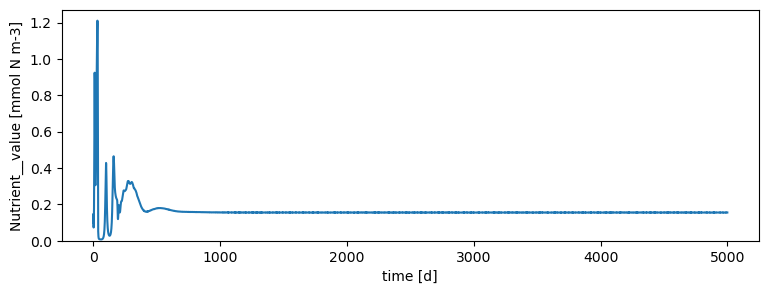

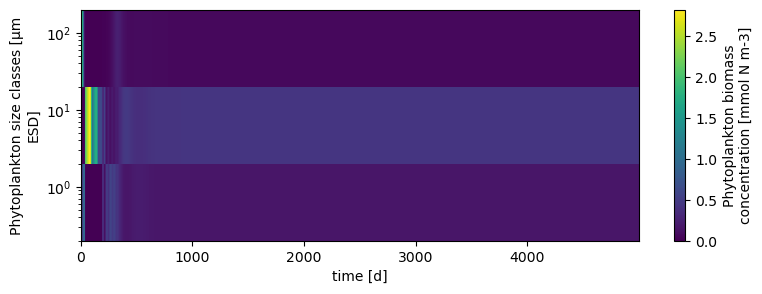

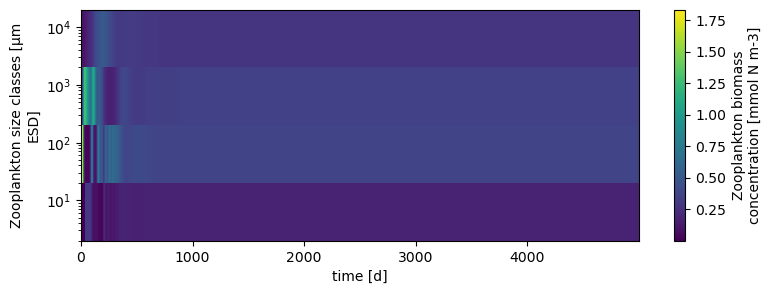

In [5]:
# plot nutrient:
model_out.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out.Phytoplankton__biomass.plot(yscale='log', aspect=3, size=3)
# zooplankton:
model_out.Zooplankton__biomass.plot(yscale='log', aspect=3, size=3)

In [7]:
P0 = model_out.Phytoplankton__biomass.isel(time=slice(365*9,365*10)).mean(dim='time').values#.plot.line(x='time')
Z0 = model_out.Zooplankton__biomass.isel(time=slice(365*9,365*10)).mean(dim='time').values
N0 = model_out.Nutrient__value.isel(time=slice(365*9,365*10)).mean(dim='time').values #+0.1
print("N",N0)
print("P",P0)
print("Z",Z0)

N 0.15519821050573837
P [0.16404959 0.43378036 0.06199158]
Z [0.17415213 0.36571029 0.34572461 0.28122413]


In [11]:
model_setup_2 = xso.setup(solver='fsolve', model=Stocketal2008,
        time=[0,1],
                                      input_vars={
                    # State variables
                    'Nutrient':{'value_label':'N','value_init':N0},
                    'Phytoplankton':{'biomass_label':'P','biomass_init':P0, 'phyto_index':phyto_sizes},
                 
                    'Zooplankton':{'biomass_label':'Z','biomass_init':Z0, 'zoo_index': zoo_sizes},
                
                    # Flows:
                    'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
                
                    # Growth
                    'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

                    # Grazing
                    'Grazing':{'resource':'P', 'consumer':'Z', 'Imax':zoo_imax, 'KsZ':zoo_Ki, 'phiPZ':zoo_prey_avail},
                    'GGE':{'grazed_phyto':'P', 'grazed_zoo':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
                           'R':zoo_frac_excreted, 'alpha':zoo_frac_assim, 'f_I':zoo_frac_egest_recycled, 'gge':zoo_gge},
                
                    # Mortality
                    'PhytoMortality':{'population':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},
                    'HigherOrderMortality':{'population':'Z', 'nutrient':'N', 'rate':zoo_mortality_array, 'exponent':zoo_mort_exponent, 'recycling':zoo_frac_mortylity_recycled},

                    # Forcings
                    'N0':{'forcing_label':'N0', 'value':nutrient_input},
            })

In [12]:
with Stocketal2008:
        model_out_2 = model_setup_2.xsimlab.run()

InitState [0.         0.15519821 0.16404959 0.43378036 0.06199158 0.17415213
 0.36571029 0.34572461 0.28122413]
[INFO] Steady state found with residual norm: 1.673382528594771e-15
Residuals: [ 0.00000000e+00  1.27675648e-15 -1.05471187e-15 -1.38777878e-16
  5.57279917e-17 -1.87350135e-16  1.38777878e-17 -5.20417043e-18
  4.33680869e-19]
YSTEADY [0.         0.15511709 0.16407546 0.43386148 0.06199433 0.17413943
 0.36570292 0.34572491 0.28122415]


In [13]:
Px = model_out_2.Phytoplankton__biomass.isel(time=1).values
Zx = model_out_2.Zooplankton__biomass.isel(time=1).values
Nx = model_out_2.Nutrient__value.isel(time=1).values
print("N",Nx)
print("P",Px)
print("Z",Zx)

N 0.15511709276727242
P [0.16407546 0.43386148 0.06199433]
Z [0.17413943 0.36570292 0.34572491 0.28122415]


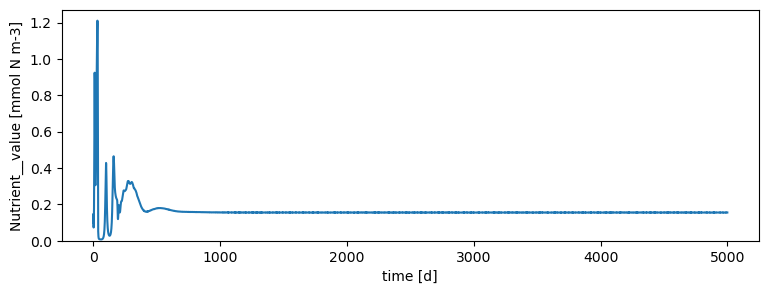

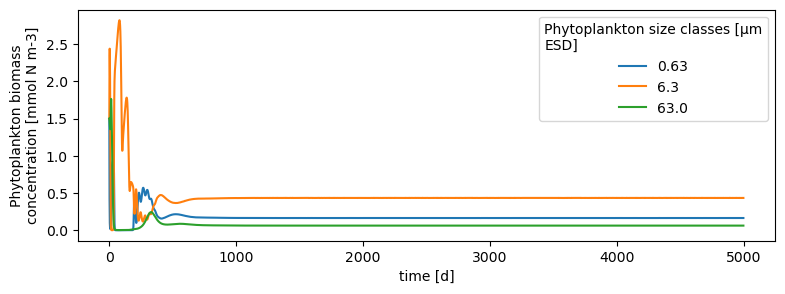

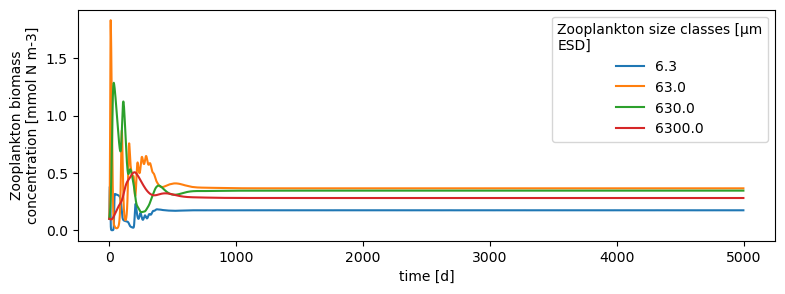

In [14]:
# plot nutrient:
model_out.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out.Phytoplankton__biomass.plot.line(x='time', aspect=3, size=3)
# zooplankton:
model_out.Zooplankton__biomass.plot.line(x='time', aspect=3, size=3)

In [18]:
Stocketal2008_mortsingleval = xso.create({
    # State variables
    'Nutrient': Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,
    'Zooplankton': ZooSizeSpectrum,

    # Flows:
    'Inflow': LinearForcingInput,

    # Growth
    'Growth': MonodGrowth_SizeBased,

    # Grazing
    'Grazing': StockGrazingMatrix,
    'GGE': Stock_GGE_MatrixGrazing,

    # Mortality
    'PhytoMortality': StockPhytoMortality,
    'HigherOrderMortality': StockZooMortality_simpleinput,

    # Forcings
    'N0': ConstantExternalNutrient,
})

model_setup_3 = xso.setup(solver='solve_ivp', model=Stocketal2008_mortsingleval,
            time=np.arange(0,5000),
            input_vars={
                    # State variables
                    'Nutrient':{'value_label':'N','value_init':1.0},
                    'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
                 
                    'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
                
                    # Flows:
                    'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
                
                    # Growth
                    'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

                    # Grazing
                    'Grazing':{'resource':'P', 'consumer':'Z', 'Imax':zoo_imax, 'KsZ':zoo_Ki, 'phiPZ':zoo_prey_avail},
                    'GGE':{'grazed_phyto':'P', 'grazed_zoo':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
                           'R':zoo_frac_excreted, 'alpha':zoo_frac_assim, 'f_I':zoo_frac_egest_recycled, 'gge':zoo_gge},
                
                    # Mortality
                    'PhytoMortality':{'population':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},
                    'HigherOrderMortality':{'population':'Z', 'nutrient':'N', 'rate':zoo_higherordermortality, 'exponent':zoo_mort_exponent, 'recycling':zoo_frac_mortylity_recycled},

                    # Forcings
                    'N0':{'forcing_label':'N0', 'value':nutrient_input},
            })

In [20]:
with Stocketal2008_mortsingleval:
        model_out_3 = model_setup_3.xsimlab.run()

No event detected


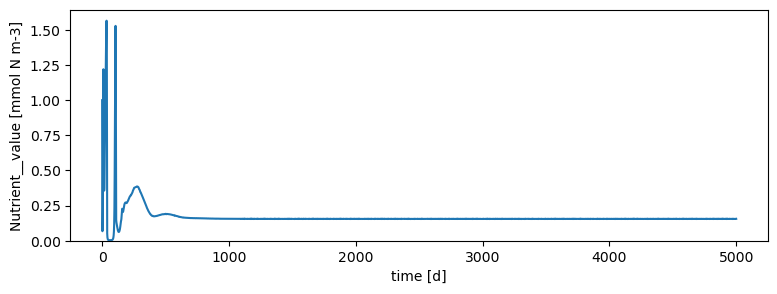

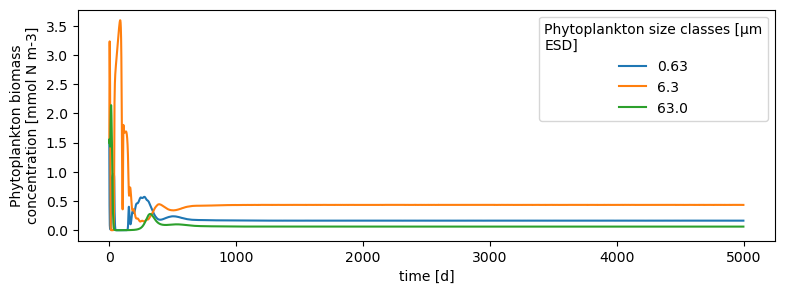

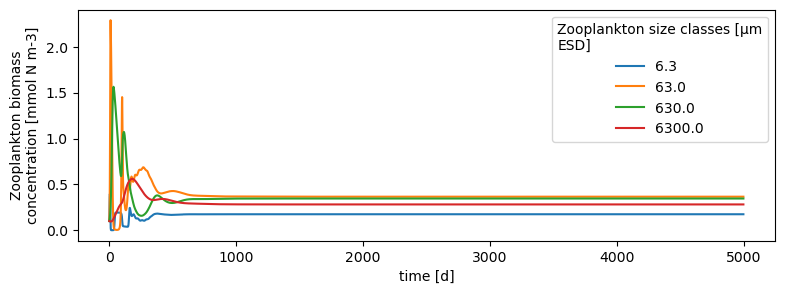

In [21]:
# plot nutrient:
model_out_3.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out_3.Phytoplankton__biomass.plot.line(x='time', aspect=3, size=3)
# zooplankton:
model_out_3.Zooplankton__biomass.plot.line(x='time', aspect=3, size=3)